# 5교시 | KV Cache(Key-Value Cache) 성능 이해
**환경**: Google Colab (T4 GPU(Graphics Processing Unit)) | **방법**: 이론 + 실습

---

## 학습 목표

- KV Cache(Key-Value Cache)가 없을 때와 있을 때의 연산량 차이를 수식으로 설명할 수 있다.
- `use_cache=True/False` 벤치마크로 속도 차이를 직접 측정한다.
- KV Cache(Key-Value Cache)의 메모리-속도 트레이드오프와 현대적 최적화 기법을 이해한다.

### 처음 읽는 분을 위한 안내

- 이번 교시를 한 줄로 보면: 이미 계산한 K, V를 다시 쓰게 해서 생성 속도를 높이는 방법을 배우는 시간이다.
- 처음에는 여기까지 이해하면 충분하다: KV Cache(Key-Value Cache)는 "과거를 다시 계산하지 않게 저장해 두는 장치"라고 이해하면 된다.
- 헷갈려도 괜찮은 부분: 메모리 공식이나 GQA(Grouped Query Attention) 비율은 처음엔 복잡해 보일 수 있다. 먼저 `속도는 빨라지지만 메모리는 더 쓴다`는 큰 원리를 잡으면 된다.

### 용어 미니사전

| 용어 | 아주 쉽게 말하면 |
|---|---|
| K, V | Attention에서 과거 토큰 정보를 저장하는 두 종류의 행렬 |
| KV Cache(Key-Value Cache) | 이전 토큰의 K, V를 저장해 두는 메모리 |
| GQA(Grouped Query Attention) | 여러 query head가 K, V를 나눠 쓰는 구조 |

---

## 이론

### KV Cache가 필요한 이유

4교시에서 구현한 Autoregressive 생성 루프를 다시 살펴보자.

```
스텝 1: "The sky is" → 모델 → "blue"
스텝 2: "The sky is blue" → 모델 → "."
스텝 3: "The sky is blue ." → 모델 → EOS
```

스텝 2에서 "The sky is"에 대한 K, V 행렬을 이미 스텝 1에서 계산했다. KV Cache 없이는 **매 스텝마다 전체 시퀀스를 처음부터 재계산**한다.

이번 차시의 핵심은 아래 한 문장으로 요약할 수 있다.

> KV Cache는 **"이전에 계산한 문맥 표현을 다시 쓰기 위한 메모리"** 다.

즉, 모델이 매번 과거를 처음부터 다시 읽지 않도록, 이전 토큰들의 K, V를 저장해 두고 다음 토큰 생성 때 재사용하는 장치다.  
Autoregressive 생성은 한 토큰씩 반복되기 때문에, 이 재사용이 없으면 같은 계산을 계속 중복하게 된다.

### 한 스텝에서 실제로 무엇이 달라질까

학습자가 가장 많이 헷갈리는 부분은 "KV Cache가 켜지면 정확히 어느 계산이 사라지는가"이다. 아래처럼 비교하면 이해가 쉽다.

1. KV Cache 없음:
    현재까지의 모든 토큰에 대해 Q, K, V를 다시 계산한다.
2. KV Cache 있음:
    새로 들어온 마지막 토큰에 대해서만 Q, K, V를 계산한다.
3. 이전 토큰들의 K, V는 캐시에 저장된 값을 그대로 재사용한다.
4. 따라서 시간이 갈수록 절약되는 계산량이 점점 커진다.

정리하면, **Cache가 줄여 주는 것은 "과거 토큰에 대한 중복 K, V 계산"** 이다.

### 연산량 비교

| 방식 | 스텝 t에서 연산량 | 전체 T 스텝 합계 |
|---|---|---|
| **KV Cache 없음** | O(t² × d) | O(T³ × d) |
| **KV Cache 있음** | O(t × d) | O(T² × d) |

→ 생성 토큰이 많아질수록 KV Cache의 이점이 **더 크게 누적**된다.

여기서 중요한 포인트는, 속도 이점이 "지수적(exponential)"으로 커지는 것은 아니라는 점이다.  
정확히는 전체 생성 길이 $T$가 커질수록 계산량 차이가 $O(T^3)$ 대 $O(T^2)$로 벌어지므로, 긴 생성에서 훨씬 유리해진다고 이해하면 된다.

### 동작 원리

```
스텝 1: Q₁, K₁, V₁ 계산
        Attention(Q₁, [K₁], [V₁]) → 출력
        KV Cache: {K: [K₁], V: [V₁]}

스텝 2: Q₂ 계산 (새 토큰만)
        K₂, V₂ 계산 (새 토큰만)
        KV Cache에 추가: {K: [K₁, K₂], V: [V₁, V₂]}
        Attention(Q₂, [K₁,K₂], [V₁,V₂]) → 출력
        ↑ K₁, V₁은 재계산하지 않음!
```

여기서 주의할 점은, Cache가 있다고 해서 Attention 자체를 생략하는 것은 아니다.  
현재 토큰의 Q는 여전히 과거의 모든 K와 비교되어야 한다. 다만 그 K, V를 다시 만들지 않을 뿐이다.

### KV Cache 메모리 크기 계산

```
KV Cache 크기 = 2 × n_layers × n_heads × seq_len × d_head × bytes_per_element

GPT-2 Small 예시 (FP32):
  = 2 × 12 × 12 × 1024 × 64 × 4 bytes
  = 75,497,472 bytes
  ≈ 72 MB (1024 토큰 기준)

LLaMA-3-8B (BF16, 32K 컨텍스트):
  = 2 × 32 × 32 × 32768 × 128 × 2 bytes
  ≈ 16.8 GB  ← 모델 가중치(16GB)와 비슷한 크기!
```

이 계산식은 아래처럼 읽으면 된다.

- `2`: K와 V 두 종류를 모두 저장해야 함
- `n_layers`: 모든 레이어에 대해 캐시가 필요함
- `d_head`: 한 Attention Head가 담당하는 벡터 길이. 보통 `d_model ÷ n_heads`로 계산하며, 예를 들어 GPT-2 Small은 `768 ÷ 12 = 64`라서 `d_head=64`가 된다.
- `n_heads × d_head`: 각 레이어의 전체 Attention 표현 크기. 즉, "헤드 수 × 헤드 하나의 폭"이라고 읽으면 된다.
- `seq_len`: 저장해야 하는 토큰 길이
- `bytes_per_element`: FP32, FP16, BF16 등에 따라 메모리 크기 결정

즉, KV Cache는 "토큰이 늘어날수록 선형으로 커지는 레이어별 메모리 저장소"라고 보면 된다.

### 메모리 vs 속도 트레이드오프

KV Cache는 **속도를 위해 메모리를 사용**한다.

- 컨텍스트가 길어질수록 KV Cache 크기가 선형으로 증가
- GPU 메모리가 가득 차면 더 이상 긴 시퀀스를 처리할 수 없음
- 이것이 LLM의 **컨텍스트 윈도우 한계**의 실질적 원인

조금 더 정확히 말하면, 컨텍스트 윈도우 한계는 모델 구조, 학습 설정, 위치 인코딩 방식 같은 요소에도 영향을 받지만, **실제 추론 시스템에서 긴 컨텍스트를 비싸게 만드는 가장 직접적인 요인 중 하나가 KV Cache 메모리**다.

즉, 긴 문맥을 처리할 수 있느냐는 단순히 모델이 "이론적으로" 지원하느냐보다, **그 길이의 KV Cache를 실제 하드웨어가 감당할 수 있느냐**와도 밀접하게 연결된다.

### 현대적 KV Cache 최적화 기법

| 기법 | 핵심 아이디어 | 적용 모델 |
|---|---|---|
| **Multi-Query Attention (MQA)** | K, V를 모든 헤드가 공유 | PaLM |
| **Grouped-Query Attention (GQA)** | 그룹별로 K, V 공유 | LLaMA 2/3 |
| **PagedAttention** | KV Cache를 페이지 단위로 관리 | vLLM 서빙 엔진 |
| **Sliding Window Attention** | 고정 윈도우 크기만 캐싱 | Mistral |

이 기법들은 모두 방향은 같다.

- 같은 품질을 유지하면서 KV Cache를 덜 쓰기
- 또는 같은 메모리로 더 긴 문맥을 처리하기
- 또는 실제 서비스에서 캐시를 더 효율적으로 배치하기

특히 교육생은 아래 두 문장만 확실히 기억하면 된다.

1. MQA/GQA는 "K, V를 여러 헤드가 공유"해서 캐시 크기를 줄인다.
2. PagedAttention은 "캐시를 저장하고 꺼내는 방식"을 최적화해 서빙 효율을 높인다.

### 이론을 읽을 때 꼭 잡아야 할 연결 고리

아래 다섯 문장을 스스로 설명할 수 있으면 이번 차시 핵심을 이해한 것이다.

1. Autoregressive 생성은 같은 과거 문맥을 여러 번 다시 참조한다.
2. KV Cache는 과거 토큰의 K, V를 저장해 중복 계산을 줄인다.
3. Cache가 있어도 현재 Q와 과거 K의 Attention 계산은 계속 필요하다.
4. 생성 길이가 길어질수록 KV Cache의 속도 이점은 더 커진다.
5. 대신 긴 컨텍스트에서는 KV Cache 메모리 사용량이 큰 부담이 된다.

---

## 실습

### 자주 막히는 오류

- 속도 차이가 작게 보임: 생성 길이가 짧으면 KV Cache 이점이 덜 드러날 수 있다.
- 첫 실행이 더 느림: 초기 로딩과 캐시 생성 비용이 포함될 수 있다.
- 메모리 계산이 헷갈림: 먼저 `레이어 수 × 토큰 수 × K/V 저장` 구조로 나눠 생각하면 쉽다.
- GQA가 왜 메모리를 줄이는지 불명확함: query 수와 kv 저장 수가 같지 않다는 점부터 보면 된다.

### 실패했을 때 체크 순서

1. 비교 조건이 같은지 확인한다: 프롬프트 길이, 생성 길이, `use_cache` 외 설정이 같아야 한다.
2. 첫 실행과 반복 실행을 구분한다: 초기 로딩 시간과 실제 생성 시간을 섞어서 읽지 않는다.
3. 속도와 메모리를 따로 본다: 하나만 좋아졌다고 전체가 좋아진 것은 아니므로 두 값을 분리해서 기록한다.

실습은 아래 순서대로 **한 단계씩 실행**하는 것을 권장한다.  
이번 차시의 실습은 크게 세 부분이다.

1. `use_cache=False`와 `use_cache=True`의 속도 차이를 측정하기
2. 생성 길이가 늘어날수록 속도 향상이 어떻게 달라지는지 시각화하기
3. 모델별 KV Cache 메모리 크기를 계산해 보기

각 코드 블록은 바로 위 설명과 연결되므로, 한 셀을 실행한 뒤 출력 결과를 확인하고 다음 셀로 넘어가면 된다.

### Step 0. 실습 준비

먼저 필요한 패키지를 설치하고 기본 라이브러리를 import한다.

In [1]:
!pip install -q transformers torch matplotlib numpy

import time
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer



이 단계에서 확인할 점:

- 패키지 설치 오류가 없는가?
- import가 정상적으로 되는가?

### Step 1. 실행 환경과 모델 준비

이번 실습에서는 GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용한다.  
또한 벤치마크를 위해 `GPT2LMHeadModel`을 로드한다.

In [ ]:
# GPU가 있으면 CUDA 사용, 없으면 CPU 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {device}")

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model.eval()

prompt = "KV Cache dramatically improves the inference speed of large language models because"

# 프롬프트를 모델 입력 형식으로 변환하고, 현재 디바이스로 이동
inputs = {k: v.to(device) for k, v in tokenizer(prompt, return_tensors="pt").items()}

print("모델 로드 완료")
print(f"프롬프트 길이: {inputs['input_ids'].shape[1]} tokens")

사용 디바이스: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

모델 로드 완료
프롬프트 길이: 13 tokens




이 단계에서 확인할 점:

- `device`가 무엇으로 잡혔는지 확인
- 프롬프트가 토큰 텐서로 잘 변환되었는지 확인

### Step 2. 벤치마크 함수 만들기

동일한 프롬프트에 대해 `use_cache` 옵션만 바꿔 평균 시간을 측정할 함수를 만든다.

In [ ]:
def benchmark(use_cache, n_tokens, n_runs=3):
    times = []

    for _ in range(n_runs):
        # GPU에서는 정확한 시간 측정을 위해 연산 동기화가 필요하다.
        if device == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        with torch.no_grad():
            model.generate(
                **inputs,
                max_new_tokens=n_tokens,
                use_cache=use_cache,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        if device == "cuda":
            torch.cuda.synchronize()

        times.append(time.perf_counter() - start)

    # 여러 번 측정한 평균값 반환
    return sum(times) / len(times)

이 단계에서 확인할 점:

- 이 함수는 "같은 프롬프트와 같은 모델로, `use_cache`만 바꿔 생성 시간을 공정하게 재는 벤치마크 도구"라고 이해하면 된다. 즉, 이후 실습에서는 이 함수를 이용해 KV Cache를 켠 경우와 끈 경우를 같은 조건에서 비교한다.
- `use_cache`는 이번 실험의 핵심 스위치다. `True`이면 KV Cache를 사용하고, `False`이면 사용하지 않는다. 따라서 이 값이 바뀌면 "과거 K, V를 재사용하느냐"만 달라지고, 나머지 조건은 최대한 같게 유지된다.
- `n_tokens`는 새로 몇 개의 토큰을 생성할지 정하는 값이다. 이 값이 커질수록 생성이 길어지고, KV Cache의 이점도 더 뚜렷하게 나타날 가능성이 커진다.
- `n_runs=3`은 한 번만 재지 않고 여러 번 반복 측정한 뒤 평균을 내기 위한 설정이다. 실행 시간은 한 번 측정만으로는 흔들릴 수 있으므로, 여러 번 재서 평균을 보는 편이 더 믿을 만하다.
- GPU에서 `torch.cuda.synchronize()`를 넣는 이유는 GPU 연산이 비동기(asynchronous)로 실행되기 때문이다. 이 동기화가 없으면 아직 GPU 계산이 끝나지 않았는데도 시간이 먼저 측정되어, 실제보다 더 짧거나 부정확한 시간이 기록될 수 있다.
- 따라서 이 단계의 핵심은 "이 함수가 단순 생성 함수가 아니라, **Cache ON/OFF를 공정한 조건에서 반복 측정하기 위한 실험용 측정기**"라는 점을 이해하는 것이다.

### Step 3. KV Cache ON/OFF 속도 비교하기

이제 생성 토큰 수를 바꿔 가며 KV Cache를 켰을 때와 껐을 때의 속도를 비교한다.

In [ ]:
print("\n[KV Cache ON vs OFF — 생성 토큰 수별 속도 비교]")
print(f"{'생성 토큰':>8} | {'Cache OFF':>12} | {'Cache ON':>12} | {'속도 향상':>10}")
print("-" * 52)

token_counts = [10, 30, 50, 100, 200, 300, 500]
results = []

for n_tokens in token_counts:
    t_off = benchmark(use_cache=False, n_tokens=n_tokens)
    t_on = benchmark(use_cache=True, n_tokens=n_tokens)
    speedup = t_off / t_on

    results.append((n_tokens, t_off, t_on, speedup))

    print(f"{n_tokens:>8} | {t_off:>9.3f}s | {t_on:>9.3f}s | {speedup:>8.2f}×")


[KV Cache ON vs OFF — 생성 토큰 수별 속도 비교]
   생성 토큰 |    Cache OFF |     Cache ON |      속도 향상
----------------------------------------------------
      10 |     0.093s |     0.114s |     0.81×
      30 |     0.295s |     0.326s |     0.90×
      50 |     0.495s |     0.531s |     0.93×
     100 |     0.970s |     1.291s |     0.75×
     200 |     2.183s |     2.261s |     0.97×
     300 |     4.247s |     3.262s |     1.30×
     500 |    11.119s |     5.602s |     1.98×


이 단계에서 확인할 점:

- 이 표의 각 행은 "같은 프롬프트로 `n_tokens`개를 생성할 때, KV Cache를 끈 경우와 켠 경우가 각각 몇 초 걸렸는가"를 보여 준다. 즉, 같은 작업을 두 번 실행해 `use_cache`만 바꿔 비교한 결과라고 읽으면 된다.
- `속도 향상` 열은 `Cache OFF 시간 ÷ Cache ON 시간`으로 계산한 값이다. 그래서 **1보다 크면 Cache ON이 더 빠른 것**이고, **1보다 작으면 이번 측정에서는 오히려 Cache ON이 더 느린 것**이다.
- 이번 결과를 보면 `10, 30, 50, 100, 200` 토큰 구간에서는 `0.81×`, `0.90×`, `0.93×`, `0.75×`, `0.97×`처럼 1보다 작거나 거의 비슷하다. 이것은 짧은 생성에서는 KV Cache의 이점이 아직 충분히 크게 드러나지 않거나, 캐시를 관리하는 오버헤드가 비슷하게 작용할 수 있음을 보여 준다.
- 반대로 `300` 토큰에서는 `1.30×`, `500` 토큰에서는 `1.98×`가 나온다. 이것은 생성이 길어질수록 과거 토큰을 다시 계산하지 않는 이점이 누적되어, KV Cache가 점점 더 유리해진다는 뜻이다.
- 따라서 이 표는 "KV Cache는 항상 모든 길이에서 즉시 압도적으로 빠르다"가 아니라, **생성이 충분히 길어질수록 점점 더 큰 이점을 만든다**는 점을 보여 주는 예시로 읽는 것이 맞다.
- 교육생이 특히 기억해야 할 포인트는, 짧은 구간의 작은 흔들림보다 전체 추세다. 이번 결과에서는 초반에는 차이가 작거나 역전되지만, 뒤로 갈수록 `Cache ON`이 더 유리해지는 방향이 분명히 나타난다.

### Step 4. 속도 향상 추이 시각화하기

앞 단계에서 얻은 결과를 그래프로 그려, 절대 시간 차이와 속도 향상 배율을 한눈에 본다.

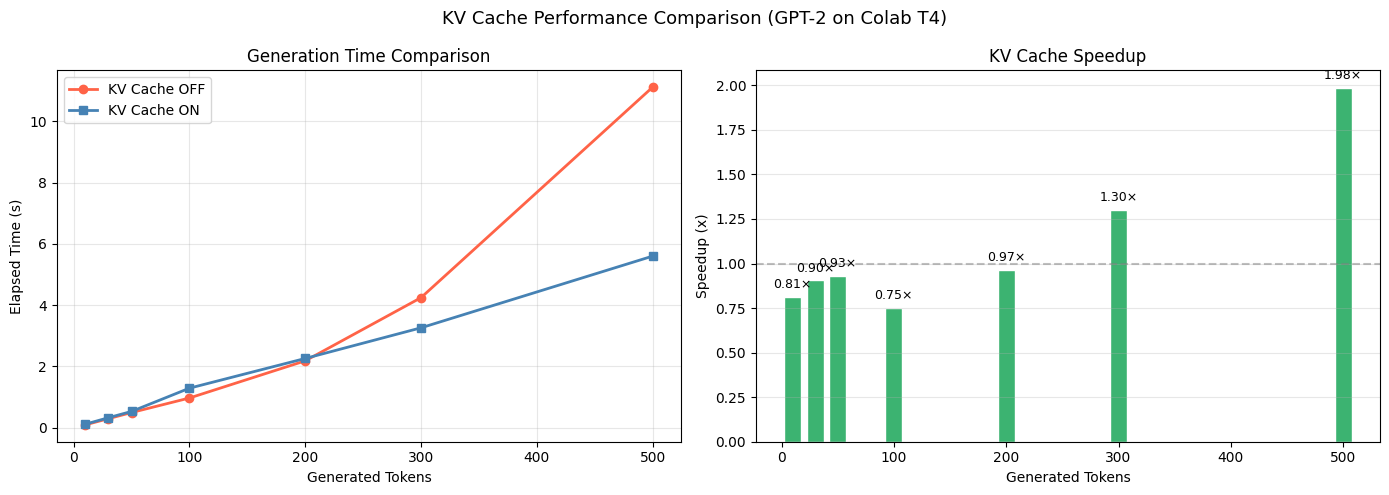

In [ ]:
ns, t_offs, t_ons, speedups = zip(*results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 절대 시간 비교
ax1.plot(ns, t_offs, "o-", color="tomato", label="KV Cache OFF", linewidth=2)
ax1.plot(ns, t_ons, "s-", color="steelblue", label="KV Cache ON", linewidth=2)
ax1.set_xlabel("Generated Tokens")
ax1.set_ylabel("Elapsed Time (s)")
ax1.set_title("Generation Time Comparison")
ax1.legend()
ax1.grid(alpha=0.3)

# 속도 향상 배율
ax2.bar(ns, speedups, color="mediumseagreen", width=15, edgecolor="white")
ax2.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Generated Tokens")
ax2.set_ylabel("Speedup (x)")
ax2.set_title("KV Cache Speedup")

for x, y in zip(ns, speedups):
    ax2.text(x, y + 0.05, f"{y:.2f}×", ha="center", fontsize=9)

ax2.grid(axis="y", alpha=0.3)

plt.suptitle("KV Cache Performance Comparison (GPT-2 on Colab T4)", fontsize=13)
plt.tight_layout()
plt.show()

이 단계에서 확인할 점:

- 이 결과는 왼쪽과 오른쪽을 **함께 읽어야** 의미가 분명해진다. 왼쪽 선 그래프는 실제 걸린 시간 자체를 보여 주고, 오른쪽 막대 그래프는 그 차이를 `몇 배 빠른가`라는 비율로 다시 보여 준다.
- 왼쪽 그래프에서 빨간선(`KV Cache OFF`)과 파란선(`KV Cache ON`)이 초반에는 비슷하게 가다가, 생성 토큰 수가 커질수록 점점 벌어지는지 본다. 특히 300토큰, 500토큰 부근에서는 빨간선이 더 가파르게 올라가므로, Cache를 끄면 생성 길이가 길어질수록 시간이 더 빠르게 늘어난다고 해석할 수 있다.
- 오른쪽 그래프의 회색 점선은 `1.0×` 기준선이다. 이 선보다 막대가 아래에 있으면 이번 측정에서는 KV Cache 이점이 아직 크지 않거나 오히려 손해였다는 뜻이고, 위에 있으면 Cache ON이 더 빠르다는 뜻이다.
- 첨부된 결과에서는 초반 막대들이 `0.81×`, `0.90×`, `0.93×`, `0.75×`, `0.97×`처럼 1 아래이거나 비슷하다. 이것은 짧은 생성에서는 Cache 관리 비용과 재사용 이점이 크게 차이 나지 않을 수 있음을 보여 준다.
- 하지만 뒤쪽으로 가면 `300토큰 = 1.30×`, `500토큰 = 1.98×`처럼 막대가 1을 분명히 넘는다. 이것은 생성이 길어질수록 KV Cache가 과거 K, V 재계산을 줄여 주는 효과가 누적되어, 실제 속도 이점이 눈에 띄게 커진다는 뜻이다.
- 따라서 이 단계의 핵심은 "초반 한두 점만 보고 판단하지 말고, 생성 길이가 길어질수록 OFF와 ON의 격차가 커지는 전체 추세를 읽는 것"이다. 이 그래프는 KV Cache의 장점이 특히 긴 생성에서 강하게 드러난다는 사실을 시각적으로 보여 준다.

### Step 5. KV Cache 메모리 크기 계산기 만들기

이번 단계에서는 속도 이점의 반대편에 있는 메모리 비용을 계산해 본다.

In [ ]:
print("\n[KV Cache 메모리 계산기]")

def kv_cache_size_mb(n_layers, n_heads, seq_len, d_model, dtype_bytes=2):
    d_head = d_model // n_heads
    size_bytes = 2 * n_layers * n_heads * seq_len * d_head * dtype_bytes
    return size_bytes / (1024 ** 2)


[KV Cache 메모리 계산기]


이 단계에서 확인할 점:

- 이 함수는 "주어진 모델 설정에서 KV Cache가 대략 몇 MB를 차지하는지 계산하는 계산기"라고 이해하면 된다. 즉, 앞에서 본 속도 이점의 반대편에 있는 **메모리 비용**을 숫자로 확인하는 도구다.
- `d_head = d_model // n_heads`는 "전체 hidden 크기(`d_model`)를 헤드 수(`n_heads`)로 나누어, 헤드 하나가 담당하는 폭을 구하는 과정"이다. 예를 들어 `d_model=768`, `n_heads=12`이면 각 head는 `64`차원을 담당한다.
- `size_bytes = 2 * n_layers * n_heads * seq_len * d_head * dtype_bytes`에서 앞의 `2`는 K와 V 두 종류를 모두 저장해야 하기 때문에 붙는다. 즉, 토큰 하나당 Key만 저장하는 것이 아니라 Value까지 함께 저장해야 한다.
- `dtype_bytes`는 숫자 하나를 저장하는 데 몇 바이트가 드는지 나타낸다. 예를 들어 FP16/BF16이면 보통 2바이트, FP32면 4바이트이므로, 같은 모델 구조라도 정밀도에 따라 KV Cache 메모리 크기가 달라질 수 있다.
- 마지막의 `size_bytes / (1024 ** 2)`는 바이트 단위를 MB로 바꾸는 단계다. 계산은 내부적으로 바이트로 하지만, 사람이 읽기에는 MB나 GB가 훨씬 직관적이기 때문이다.
- 따라서 이 단계의 핵심은 "KV Cache 크기는 레이어 수, 헤드 수, 시퀀스 길이, head 크기, 데이터 타입이 함께 결정하며, 특히 시퀀스 길이가 길어질수록 빠르게 부담이 커진다"는 점을 함수 구조로 이해하는 것이다.

### Step 6. 모델별 KV Cache 크기 비교하기

이제 여러 모델 설정을 넣어 KV Cache 메모리가 어느 정도 필요한지 비교한다.

In [ ]:
models_info = {
    "GPT-2 Small": dict(n_layers=12, n_heads=12, seq_len=1024, d_model=768),
    "GPT-2 XL": dict(n_layers=48, n_heads=25, seq_len=1024, d_model=1600),
    "LLaMA-3-8B": dict(n_layers=32, n_heads=32, seq_len=8192, d_model=4096),
    "LLaMA-3-70B": dict(n_layers=80, n_heads=64, seq_len=8192, d_model=8192),
}

print(f"{'모델':<20} | {'레이어':>6} | {'헤드':>5} | {'시퀀스':>8} | {'KV Cache 크기':>15}")
print("-" * 65)

for name, cfg in models_info.items():
    mb = kv_cache_size_mb(**cfg)
    unit = f"{mb:.1f} MB" if mb < 1024 else f"{mb / 1024:.2f} GB"

    print(
        f"{name:<20} | {cfg['n_layers']:>6} | {cfg['n_heads']:>5} | "
        f"{cfg['seq_len']:>8,} | {unit:>15}"
    )

모델                   |    레이어 |    헤드 |      시퀀스 |     KV Cache 크기
-----------------------------------------------------------------
GPT-2 Small          |     12 |    12 |    1,024 |         36.0 MB
GPT-2 XL             |     48 |    25 |    1,024 |        300.0 MB
LLaMA-3-8B           |     32 |    32 |    8,192 |         4.00 GB
LLaMA-3-70B          |     80 |    64 |    8,192 |        20.00 GB


이 단계에서 확인할 점:

- 이 표는 "모델 크기와 컨텍스트 길이가 달라지면 KV Cache 메모리가 얼마나 커지는가"를 한눈에 보여 준다. 즉, KV Cache는 단순히 조금 늘어나는 수준이 아니라, 모델이 커질수록 매우 빠르게 부담이 커질 수 있음을 숫자로 보여 주는 단계다.
- `GPT-2 Small = 36.0 MB`, `GPT-2 XL = 300.0 MB`를 비교하면, 같은 1024 토큰 컨텍스트라도 레이어 수와 모델 크기가 커지면 KV Cache 메모리가 크게 증가한다는 점을 볼 수 있다. 즉, 작은 모델에서는 비교적 가볍지만, 모델이 커질수록 캐시도 함께 무거워진다.
- `LLaMA-3-8B = 4.00 GB`, `LLaMA-3-70B = 20.00 GB`는 더 강한 메시지를 준다. 대형 모델에서는 KV Cache만으로도 수 GB에서 수십 GB가 필요할 수 있으므로, 실제 서비스에서는 이 메모리 비용이 매우 큰 제약이 된다.
- 특히 여기서는 `seq_len`이 `1024`에서 `8192`로 길어져 있다. KV Cache는 시퀀스 길이에 비례해 커지므로, 긴 컨텍스트를 지원하는 모델일수록 "모델 자체가 큰 것"뿐 아니라 "저장해야 할 토큰 수도 많은 것"이 함께 겹쳐 부담이 더 커진다.
- 교육생이 감각적으로 기억해야 할 포인트는, KV Cache가 속도 최적화 장치이긴 하지만 공짜가 아니라는 점이다. 예를 들어 `20.00 GB`는 단순한 보조 메모리가 아니라, GPU 메모리 대부분을 차지할 수 있을 정도로 큰 값이다.
- 따라서 이 단계의 핵심은 "대형 모델 + 긴 컨텍스트" 조합에서는 KV Cache가 매우 큰 메모리 비용이 되며, 그래서 MQA, GQA 같은 최적화 기법이 실전에서 중요해진다"는 점을 표 숫자와 연결해서 이해하는 것이다.

### 실습을 마친 뒤 정리

위 실습이 끝나면 아래 내용을 말로 설명할 수 있어야 한다.

1. KV Cache는 과거 토큰의 K, V를 재사용해 속도를 높인다.
2. 생성 길이가 길어질수록 `use_cache=True`의 이점이 더 커진다.
3. KV Cache는 속도를 높이는 대신 메모리를 더 사용한다.
4. 대형 모델과 긴 컨텍스트에서는 KV Cache 메모리 비용이 매우 커진다.
5. 그래서 현대 모델은 GQA, MQA 같은 기법으로 KV Cache 부담을 줄이려 한다.

**관찰 과제**

1. 생성 토큰이 많아질수록 속도 향상 배율이 커지는 추이 확인
2. LLaMA-3-70B의 KV Cache가 모델 가중치 크기에 육박하는 이유 이해
3. GQA(Grouped-Query Attention)가 KV Cache 메모리를 줄이는 원리 토론

---

## 핵심 개념 정리

```
KV Cache = "이미 계산한 K, V를 저장해두고 재사용"
  장점: 추론 속도 대폭 향상 (토큰이 많을수록 효과↑)
  단점: VRAM 사용량 증가 (컨텍스트가 길수록 더 많이 사용)
  
현대 LLM의 컨텍스트 한계는 대부분 KV Cache 메모리 문제다.
```

### 혼자 점검하기

아래 질문에 막힘 없이 답하면 이론 이해가 잘 된 것이다.

1. KV Cache가 없으면 왜 같은 계산이 반복되는가?
2. KV Cache가 있어도 여전히 매 스텝 수행해야 하는 계산은 무엇인가?
3. 생성 길이가 길어질수록 KV Cache의 이점이 커지는 이유는 무엇인가?
4. KV Cache 메모리 크기 식에서 `2`가 붙는 이유는 무엇인가?
5. MQA와 GQA는 어떤 방식으로 KV Cache 부담을 줄이는가?

---

## 다음 교시 예고

**6교시**: 이미지를 LLM에 입력하려면 어떻게 해야 할까? ViT가 이미지를 패치로 분할하여 텍스트 토큰과 같은 형식으로 변환하는 과정을 시각화한다.

---

## 부록 | 관찰 과제·혼자 점검 모범 답안

이 부록은 교육생이 실습과 이론을 마친 뒤 스스로 이해를 점검할 수 있도록 만든 해설이다.  
정답을 그대로 외우기보다, **벤치마크 결과와 메모리 계산 값을 보고 설명할 수 있는지**를 기준으로 활용하면 된다.

### 관찰 과제 모범 답안

**1. 생성 토큰이 많아질수록 속도 향상 배율이 커지는 추이 확인**

생성 길이가 짧을 때는 KV Cache의 이점이 상대적으로 작게 보일 수 있지만, 생성 토큰 수가 늘어날수록 `use_cache=True`와 `use_cache=False`의 차이가 더 크게 벌어진다. 이는 KV Cache가 과거 토큰의 K, V를 다시 계산하지 않도록 해 주기 때문이다. 즉, 생성이 길어질수록 중복 계산 절감 효과가 더 크게 누적된다.

**2. LLaMA-3-70B의 KV Cache가 모델 가중치 크기에 육박하는 이유 이해**

대형 모델은 레이어 수, 헤드 수, `d_model`, 컨텍스트 길이가 모두 크기 때문에 KV Cache도 매우 커진다. 특히 긴 컨텍스트에서는 각 레이어마다 모든 토큰의 K, V를 저장해야 하므로 메모리 사용량이 급격히 증가한다. 그래서 대형 모델에서는 가중치만큼이나 KV Cache 메모리가 큰 부담이 될 수 있다.

**3. GQA(Grouped-Query Attention)가 KV Cache 메모리를 줄이는 원리 토론**

GQA는 여러 query head가 K, V를 그룹 단위로 공유하도록 만든다. 즉, 모든 head가 각자 독립적인 K, V를 저장하지 않고 일부를 함께 쓰기 때문에 KV Cache 크기를 줄일 수 있다. 결과적으로 메모리 사용량이 감소하고, 더 긴 컨텍스트나 더 큰 배치를 다루기 쉬워진다.

### 혼자 점검하기 모범 답안

**1. KV Cache가 없으면 왜 같은 계산이 반복되는가?**

Autoregressive 생성에서는 매 스텝마다 이전까지의 전체 문맥을 다시 입력으로 사용한다. KV Cache가 없으면 그때마다 과거 토큰들의 K, V도 처음부터 다시 계산해야 한다. 즉, 이미 계산한 과거 문맥 표현을 계속 반복해서 만드는 비효율이 생긴다.

**2. KV Cache가 있어도 여전히 매 스텝 수행해야 하는 계산은 무엇인가?**

새로 들어온 현재 토큰의 Q, K, V 계산은 계속 필요하다. 또한 현재 Q와 과거 K 사이의 attention 계산도 여전히 수행해야 한다. KV Cache가 줄여 주는 것은 과거 토큰들의 K, V 재계산이지, Attention 전체를 없애는 것은 아니다.

**3. 생성 길이가 길어질수록 KV Cache의 이점이 커지는 이유는 무엇인가?**

생성 길이가 길어질수록 과거 토큰 수가 많아지고, 재계산해야 할 양도 커진다. KV Cache가 있으면 이 과거 부분을 다시 계산하지 않아도 되므로 절약되는 양이 점점 커진다. 따라서 긴 생성일수록 속도 차이가 더 뚜렷하게 나타난다.

**4. KV Cache 메모리 크기 식에서 `2`가 붙는 이유는 무엇인가?**

Attention에서 저장해야 하는 것은 K와 V 두 종류의 행렬이기 때문이다. 즉, 각 토큰에 대해 Key와 Value를 모두 보관해야 하므로 메모리 식 앞에 `2`가 붙는다.

**5. MQA와 GQA는 어떤 방식으로 KV Cache 부담을 줄이는가?**

MQA는 여러 head가 하나의 K, V를 공유하게 하고, GQA는 head를 몇 개의 그룹으로 묶어 그룹별로 K, V를 공유하게 한다. 둘 다 핵심은 "모든 head가 완전히 독립적인 K, V를 들고 있지 않게 만드는 것"이다. 이를 통해 KV Cache 메모리를 줄이고, 추론 효율을 개선할 수 있다.

### 활용 팁

이 부록은 아래 순서로 복습할 때 가장 효과적이다.

1. 먼저 벤치마크 표와 그래프를 보고 스스로 해석해 본다.
2. 그다음 모범 답안과 비교한다.
3. 숫자가 조금 달라도 추세를 올바르게 설명하면 이해한 것으로 본다.
4. 설명이 막히면 다시 속도 그래프와 메모리 계산 표를 확인한다.